In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [55]:
with open('Beta_sensitivity_0.65.json') as json_file:
    F_results = json.load(json_file)


In [56]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [57]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
# df


In [58]:
obj_sum = df.Value.sum()

# Create a dictionary with the result
result_dict = {'beta_value': 0.65, 'sum': obj_sum}

# Specify the path for the output JSON file
output_json_path = 'unvaccinated_children_totals.json'  # Replace with the desired path

# Write the result to a JSON file
with open(output_json_path, 'a') as json_file:
    json_file.write('\n')
    json.dump(result_dict,json_file)

print(f"Sum of 'OBJ' column written to {output_json_path}")

Sum of 'OBJ' column written to unvaccinated_children_totals.json


In [59]:
# import pandas as pd

# # Assuming df is your DataFrame
# # If not, replace df with your DataFrame variable name

# # Grouping and counting
# result = df.groupby(['Antigen', 'Year'])['Value'].sum().reset_index()
# result = result[result['Value'] != 0.0]
# # Filtering only years 1-10
# new = result[result['Year'].between(1, 9)]

# # Grouping by Antigen and summing the Value column
# # result = df.groupby('Antigen')['Value'].sum().reset_index()

# # Displaying the result
# print(new)


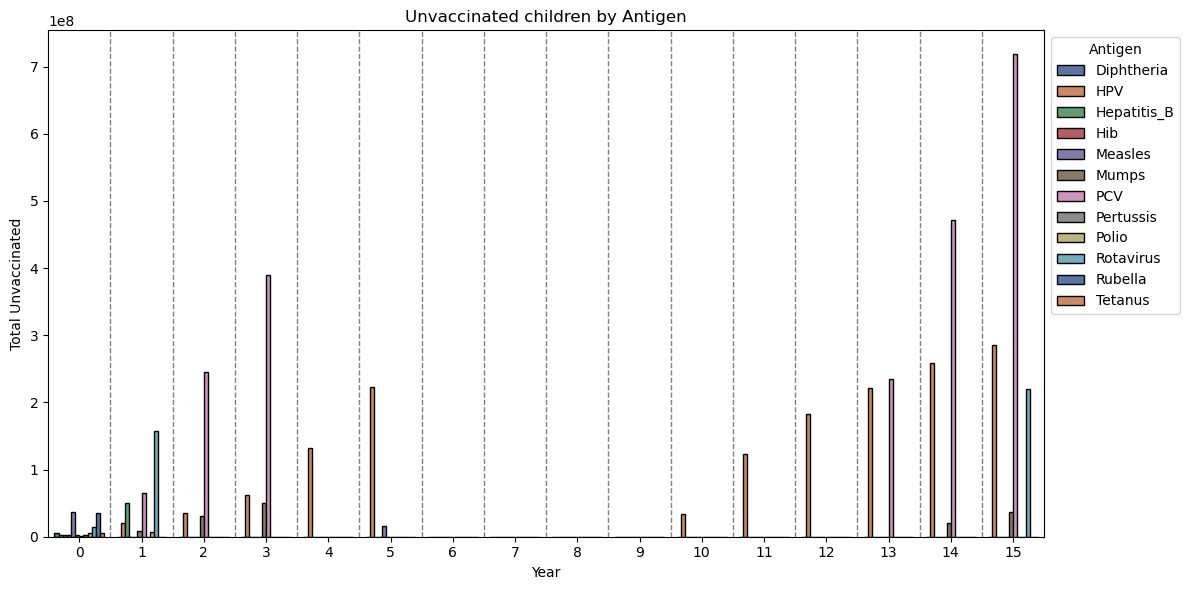

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(0, 16))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()
result = result[result['Year'].between(0, 15)]

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Set a color palette with distinct colors for each antigen
palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes

# Add vertical lines at each break between years (1 to 10)
for year in all_years[1:]:
    plt.axvline(x=year - 0.5, color='gray', linestyle='--', linewidth=1)

plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout for better visualization
plt.savefig('Unvax_children_beta_0.65.png')
plt.show()


##### 